In [1]:
# Mount Google Drive (always run this first)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imports
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:
# Unzip dataset (always run — it's fast and temporary)
import zipfile

zip_path     = '/content/drive/MyDrive/cats-dogs-project/archive.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done unzipping!")

Done unzipping!


In [ ]:
# Data Cleaning — Remove Corrupted Images
def remove_corrupted_images(folder):
    """
    Scans a directory recursively and deletes any image files that
    cannot be opened or are corrupted beyond recovery.

    Parameters:
        folder (str): Root directory to scan for corrupted images.

    Returns:
        int: Number of corrupted images removed.
    """
    from PIL import Image
    removed = 0

    for root, dirs, files in os.walk(folder):
        for fname in files:
            if fname.endswith('.jpg'):
                fpath = os.path.join(root, fname)
                try:
                    img = Image.open(fpath)
                    img.verify()
                except Exception:
                    os.remove(fpath)
                    removed += 1

    print(f"Removed {removed} corrupted images from {folder}")
    return removed

# Run on local training data
remove_corrupted_images('/content/local_data/train')
remove_corrupted_images('/content/local_data/validation')
remove_corrupted_images('/content/local_data/test')

In [4]:
# Split data into train/validation/test (skips if already done)
base     = '/content/drive/MyDrive/cats-dogs-project/data'
cats_dir = '/content/data/PetImages/Cat'
dogs_dir = '/content/data/PetImages/Dog'

def split_and_copy(src_dir, category):
    files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]
    random.shuffle(files)
    n = len(files)

    splits = {
        'train':      files[:int(0.8 * n)],
        'validation': files[int(0.8 * n):int(0.9 * n)],
        'test':       files[int(0.9 * n):]
    }

    for split, filelist in splits.items():
        os.makedirs(f'{base}/{split}/{category}', exist_ok=True)
        for fname in filelist:
            shutil.copy(
                f'{src_dir}/{fname}',
                f'{base}/{split}/{category}/{fname}'
            )

    print(f'{category} → train: {len(splits["train"])}, '
          f'val: {len(splits["validation"])}, test: {len(splits["test"])}')

already_split = (
    os.path.exists(f'{base}/train/cats') and
    len(os.listdir(f'{base}/train/cats')) > 0
)

if already_split:
    print("Data already split on Drive — skipping.")
else:
    print("Splitting data... (this takes 5–10 minutes)")
    split_and_copy(cats_dir, 'cats')
    split_and_copy(dogs_dir, 'dogs')
    print("Split complete!")

Data already split on Drive — skipping.


In [5]:
# Copy data from Drive to Colab local storage for fast training
#              (skips if already copied this session)
local_base = '/content/local_data'

already_local = (
    os.path.exists(f'{local_base}/train') and
    len(os.listdir(f'{local_base}/train')) > 0
)

if already_local:
    print("Data already copied locally — skipping.")
else:
    print("Copying data from Drive to Colab... (3–5 mins, once per session)")
    shutil.copytree(f'{base}/train',      f'{local_base}/train')
    shutil.copytree(f'{base}/validation', f'{local_base}/validation')
    shutil.copytree(f'{base}/test',       f'{local_base}/test')
    print("Done! Data is now local.")

Copying data from Drive to Colab... (3–5 mins, once per session)
Done! Data is now local.


In [6]:
# Load data generators (reads from local Colab storage)



train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{local_base}/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)


val_generator = val_datagen.flow_from_directory(
    f'{local_base}/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    f'{local_base}/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 19998 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [7]:
import os

base = '/content/drive/MyDrive/cats-dogs-project/data'

for split in ['train', 'validation', 'test']:
    for category in ['cats', 'dogs']:
        path = f'{base}/{split}/{category}'
        if os.path.exists(path):
            print(f'{split}/{category}: {len(os.listdir(path))} images')
        else:
            print(f'{split}/{category}: MISSING')

train/cats: 9999 images
train/dogs: 9999 images
validation/cats: 1250 images
validation/dogs: 1250 images
test/cats: 1250 images
test/dogs: 1250 images


In [8]:
import shutil

# Remove the incomplete local copy
if os.path.exists('/content/local_data'):
    shutil.rmtree('/content/local_data')

# Redo the copy
local_base = '/content/local_data'
for split in ['train', 'validation', 'test']:
    shutil.copytree(f'{base}/{split}', f'{local_base}/{split}')
    print(f'Copied {split}/')

Copied train/
Copied validation/
Copied test/


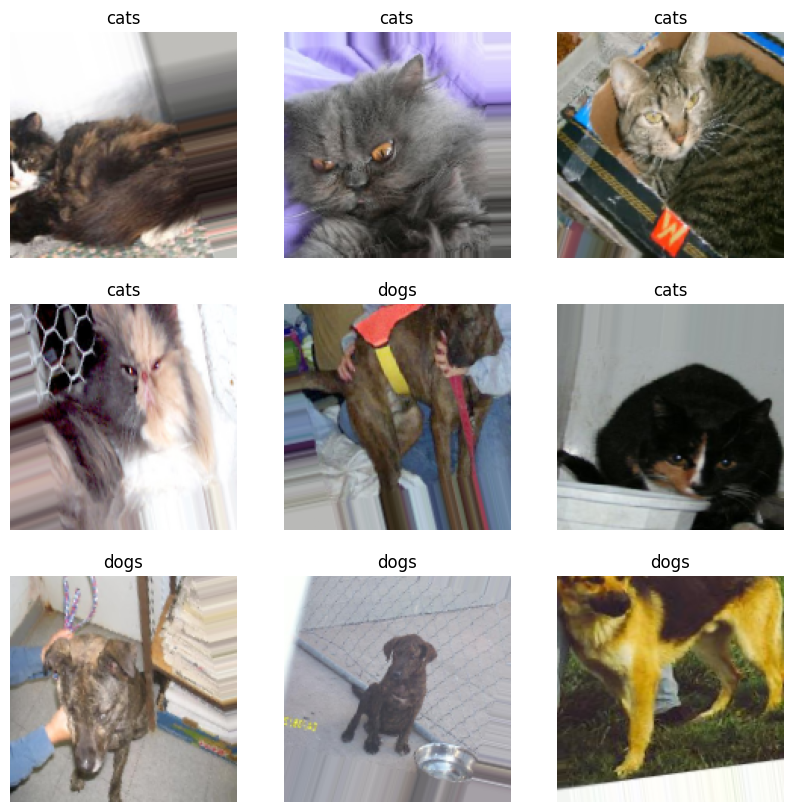

In [9]:
# Visualize sample images
images, labels = next(train_generator)
class_names = ['cats', 'dogs']

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.show()

In [10]:
# Build or load model
model_path = '/content/drive/MyDrive/cats-dogs-project/model.keras'

if os.path.exists(model_path):
    model = load_model(model_path)
    print("Model loaded from Drive — skipping training!")
    model_loaded = True
else:
    print("No saved model found — building from scratch...")
    model_loaded = False

    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),

        # Block 1 — finds basic features like edges and corners
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 2 — finds more complex features like eyes and ears
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 3 — finds high level features like faces and tails
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Flatten and classify
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # 0 = cat, 1 = dog
    ])

    model.summary()

Model loaded from Drive — skipping training!


In [11]:
# Compile and train (skips if model was loaded)
if not model_loaded:
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_generator,
        epochs=20,
        validation_data=val_generator
    )

    # Save model to Drive so you never retrain again
    model.save(model_path)
    print("Model saved to Drive!")

In [12]:
# Plot training history (only if we just trained)
if not model_loaded:
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Loss')
    plt.legend()

    plt.show()

In [13]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8930 - loss: 0.2700

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8944 - loss: 0.2610

Test Accuracy: 89.44%
Test Loss:     0.2610


In [14]:
pip install gradio

In [19]:
print("Shuffle setting:", test_generator.shuffle)

Shuffle setting: False


In [20]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    f'{local_base}/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False        # critical for confusion matrix to align correctly
)

Found 2500 images belonging to 2 classes.


77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step


<Figure size 600x500 with 0 Axes>

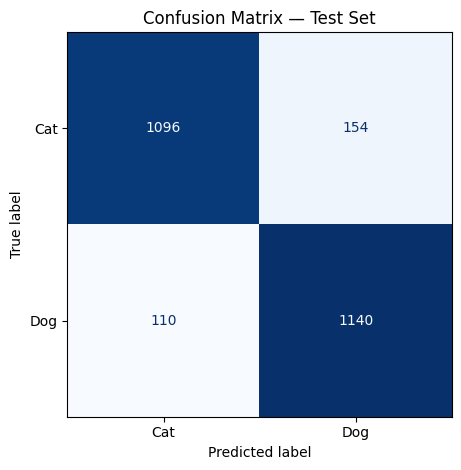


Correctly identified cats : 1096
Correctly identified dogs : 1140
Cats misidentified as dogs: 154
Dogs misidentified as cats: 110


In [21]:
# Confusion Matrix
def plot_confusion_matrix(model, test_generator):
    """
    Generates and plots a confusion matrix on the test set,
    showing correct and incorrect predictions for each class.

    Parameters:
        model: Trained Keras model.
        test_generator: Keras data generator for the test set
                        (must have shuffle=False).

    Returns:
        None
    """
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Get true labels
    true_labels = test_generator.classes

    # Get model predictions (raw probabilities)
    predictions = model.predict(test_generator)

    # Convert probabilities to 0 or 1
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    # Build confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plot
    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Cat', 'Dog']
    )
    disp.plot(cmap='Blues', colorbar=False)
    plt.title('Confusion Matrix — Test Set')
    plt.tight_layout()
    plt.show()

    # Print readable summary
    tn, fp, fn, tp = cm.ravel()
    print(f"\nCorrectly identified cats : {tn}")
    print(f"Correctly identified dogs : {tp}")
    print(f"Cats misidentified as dogs: {fp}")
    print(f"Dogs misidentified as cats: {fn}")

plot_confusion_matrix(model, test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


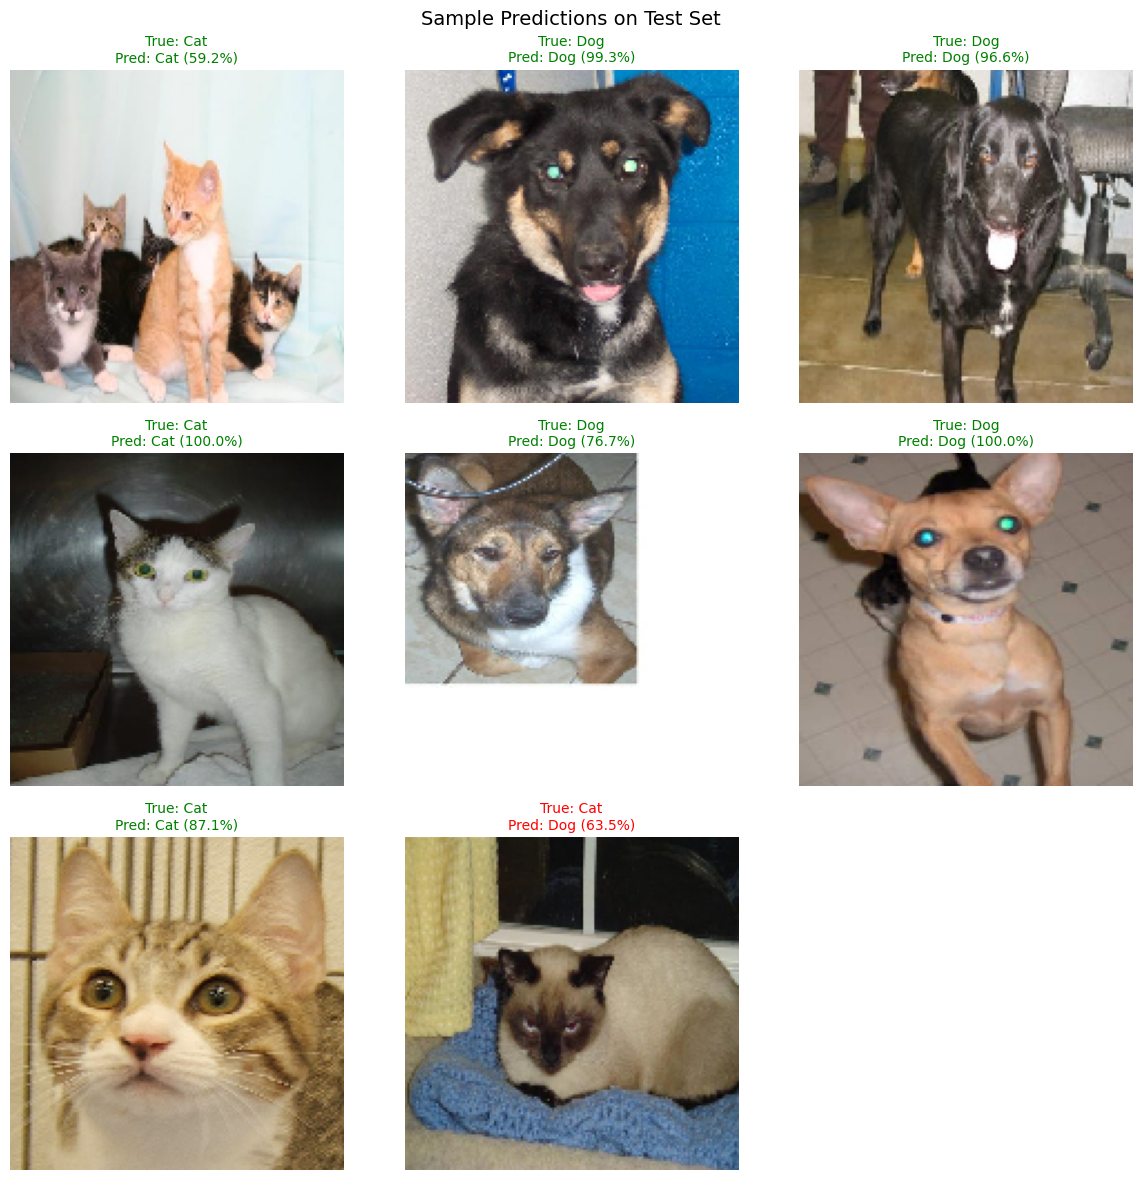

In [24]:
# Sample Predictions Grid (mixed cats and dogs)
from tensorflow.keras.preprocessing import image as keras_image

def plot_sample_predictions(model, test_dir, n_per_class=4):
    """
    Displays a grid of test images with true label, predicted label,
    and confidence score, sampling images from both the cats and dogs
    test folders directly. Correct predictions shown in green,
    incorrect ones in red.

    Parameters:
        model: Trained Keras model.
        test_dir (str): Path to the test directory containing
                         'cats' and 'dogs' subfolders.
        n_per_class (int): Number of images to sample from each class.

    Returns:
        None
    """
    class_names = ['Cat', 'Dog']
    samples = []  # will hold (image_array, true_label)

    for label, category in enumerate(['cats', 'dogs']):
        folder = f'{test_dir}/{category}'
        files = random.sample(os.listdir(folder), n_per_class)
        for fname in files:
            img = keras_image.load_img(f'{folder}/{fname}', target_size=(150, 150))
            img_array = keras_image.img_to_array(img) / 255.0
            samples.append((img_array, label))

    random.shuffle(samples)  # mix cats and dogs in the grid

    images = np.array([s[0] for s in samples])
    true_labels = [s[1] for s in samples]

    predictions = model.predict(images)
    n = len(samples)
    cols = int(np.ceil(n ** 0.5))

    plt.figure(figsize=(12, 12))
    for i in range(n):
        plt.subplot(cols, cols, i + 1)
        plt.imshow(images[i])

        true_label = class_names[true_labels[i]]
        pred_prob  = predictions[i][0]
        pred_label = "Dog" if pred_prob > 0.5 else "Cat"
        confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob

        is_correct = (true_label == pred_label)
        color = 'green' if is_correct else 'red'

        plt.title(
            f"True: {true_label}\nPred: {pred_label} ({confidence*100:.1f}%)",
            color=color, fontsize=10
        )
        plt.axis('off')

    plt.suptitle('Sample Predictions on Test Set', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_sample_predictions(model, f'{local_base}/test', n_per_class=4)

In [15]:
# building interface
# Load saved model from Drive
model = load_model('/content/drive/MyDrive/cats-dogs-project/model.keras')

def predict(img):
    # Resize and normalize the uploaded image
    img = img.resize((150, 150))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Dog"
        confidence = prediction
    else:
        label = "Cat"
        confidence = 1 - prediction

    return f"{label} ({confidence * 100:.2f}% confidence)"

# Build the interface
app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Text(label="Prediction"),
    title="Cats vs Dogs Classifier",
    description="Upload any image of a cat or dog and the model will identify it."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e48f2bb228de7a26bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
